In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from utils import load_data, get_regression_split

TARGET = "CC50, mM"

# Регрессия: CC50

## Данные

In [2]:
df = load_data()
X_train, X_test, y_train, y_test = get_regression_split(df, TARGET, log_transform=True)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

Train: (800, 192), Test: (201, 192)


## Модели

In [3]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
    "RandomForest": RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=300, max_depth=5, learning_rate=0.1, random_state=42),
    "SVR": SVR(C=10, kernel="rbf"),
}

results = []
fitted_models = {}

for name, model in models.items():
    use_scaled = name in ["LinearRegression", "Ridge", "Lasso", "ElasticNet", "SVR"]
    Xtr = X_train_sc if use_scaled else X_train
    Xte = X_test_sc if use_scaled else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    y_test_orig = np.expm1(y_test)
    y_pred_orig = np.expm1(y_pred)

    results.append({
        "Model": name,
        "MAE (log)": round(mean_absolute_error(y_test, y_pred), 4),
        "RMSE (log)": round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        "R2 (log)": round(r2_score(y_test, y_pred), 4),
        "MAE (orig)": round(mean_absolute_error(y_test_orig, y_pred_orig), 2),
        "RMSE (orig)": round(np.sqrt(mean_squared_error(y_test_orig, y_pred_orig)), 2),
        "R2 (orig)": round(r2_score(y_test_orig, y_pred_orig), 4),
    })
    fitted_models[name] = (model, use_scaled)

results_df = pd.DataFrame(results).sort_values("R2 (log)", ascending=False)
results_df


,Model,MAE (log),RMSE (log),R2 (log),MAE (orig),RMSE (orig),R2 (orig)
4,RandomForest,0.8131,1.1245,0.4440,305.85,522.59,0.4732
6,SVR,0.8288,1.1763,0.3916,303.04,507.50,0.5032
5,GradientBoosting,0.8210,1.1844,0.3832,284.22,493.63,0.5300
2,Lasso,0.9211,1.2114,0.3548,367.63,601.62,0.3019
3,ElasticNet,0.9885,1.2232,0.3421,413.45,702.61,0.0478
1,Ridge,0.9371,1.2477,0.3155,373.38,602.94,0.2988
0,LinearRegression,1.0118,1.3780,0.1650,475.11,1226.74,-1.9027


In [5]:
tuned_models = {}

rf_gs = GridSearchCV(
    RandomForestRegressor(random_state=42),
    {"n_estimators": [200, 400], "max_depth": [8, 12, None], "min_samples_leaf": [1, 3]},
    cv=5, scoring="neg_mean_squared_error", n_jobs=-1
)
rf_gs.fit(X_train, y_train)
tuned_models["RandomForest"] = rf_gs.best_estimator_
print(f"RF best: {rf_gs.best_params_}")

gbm_gs = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    {"n_estimators": [200, 400], "max_depth": [3, 5], "learning_rate": [0.05, 0.1]},
    cv=5, scoring="neg_mean_squared_error", n_jobs=-1
)
gbm_gs.fit(X_train, y_train)
tuned_models["GradientBoosting"] = gbm_gs.best_estimator_
print(f"GBM best: {gbm_gs.best_params_}")

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    y_test_orig = np.expm1(y_test)
    y_pred_orig = np.expm1(y_pred)
    print(f"{name} (tuned):")
    print(f"R2 (log): {r2_score(y_test, y_pred):.4f}")
    print(f"R2 (orig): {r2_score(y_test_orig, y_pred_orig):.4f}")
    fitted_models[name] = (model, False)


RF best: {'max_depth': 12, 'min_samples_leaf': 3, 'n_estimators': 200}
GBM best: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}
RandomForest (tuned):
R2 (log): 0.4375
R2 (orig): 0.4869
GradientBoosting (tuned):
R2 (log): 0.3749
R2 (orig): 0.5125


## Feature importance (лучшая модель)

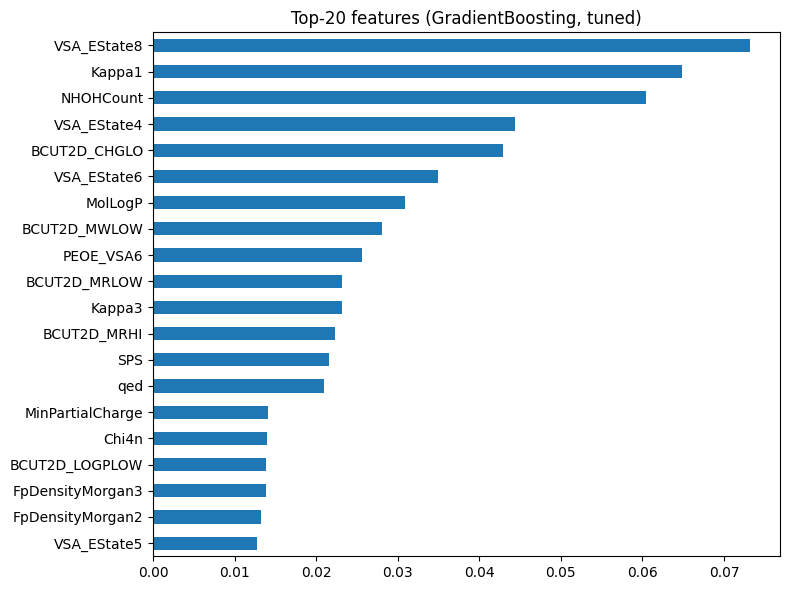

In [7]:
best_name = "GradientBoosting"
best_model = tuned_models[best_name]

feat_imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_title(f"Top-20 features ({best_name}, tuned)")
plt.tight_layout()
plt.show()


## Residual plot

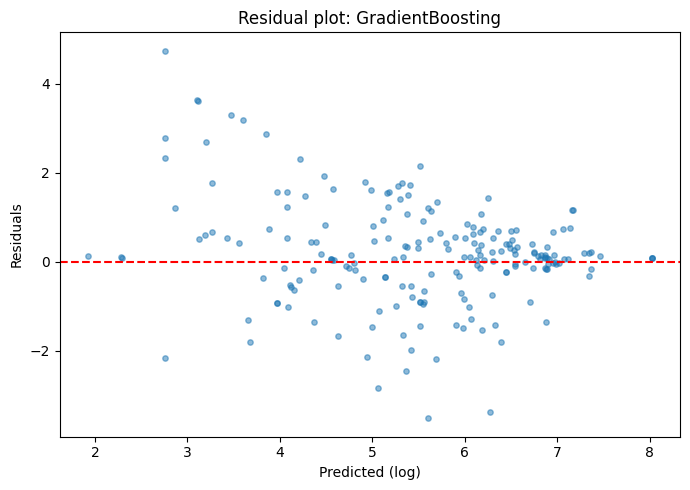

In [8]:
best_model, use_scaled = fitted_models[best_name]
Xte = X_test_sc if use_scaled else X_test
y_pred = best_model.predict(Xte)
residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_pred, residuals, alpha=0.5, s=15)
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("Predicted (log)")
ax.set_ylabel("Residuals")
ax.set_title(f"Residual plot: {best_name}")
plt.tight_layout()
plt.show()

## Выводы

Интересно, что GBM в оригинальных единицах (R2=0.51) лучше RF (0.49), хотя в log-пространстве наоборот. Видимо GBM лучше справляется с восстановлением больших значений CC50. Тот же набор признаков, что и для IC50 - VSA_EState, Kappa, MolLogP.